In [1]:
import sys
import pandas as pd
import numpy as np
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
sys.path.insert(0, '../')

from src import RepositorioDados
from src import evaluate_and_visualize

# Detecta o dispositivo e a precisão usada nas operações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | Precision: torch.float32


In [2]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
ID_COLUMNS = []             # Sem IDs (série única)

FORECAST_HORIZON = 1        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

Carregando modelo: context256_lags3_useTrue
Configurações extraídas - Context Length: 256, Lags: 3, Use Mean Features: False
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade



=== Scratch ===
MSE: 8.168702e-07
MAE: 3.783845e-04
RMSE: 9.038087e-04
MAPE: 1.023528e+02


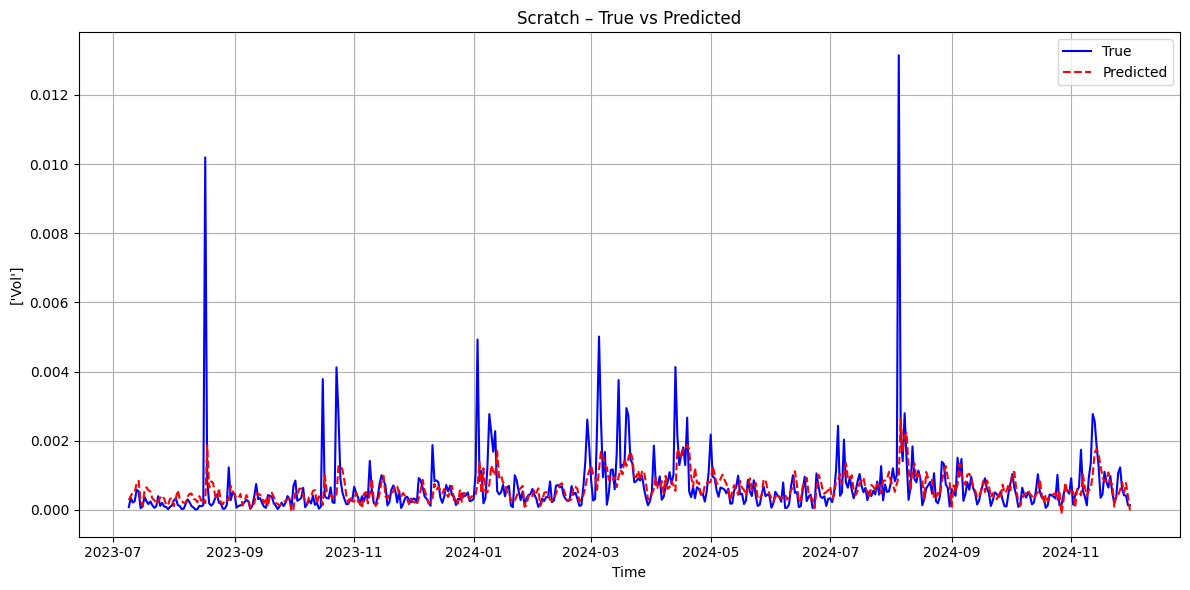

Carregando modelo: context256_lags5_useFalse
Configurações extraídas - Context Length: 256, Lags: 5, Use Mean Features: False
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade



=== Scratch ===
MSE: 8.078752e-07
MAE: 3.659714e-04
RMSE: 8.988188e-04
MAPE: 9.039714e+01


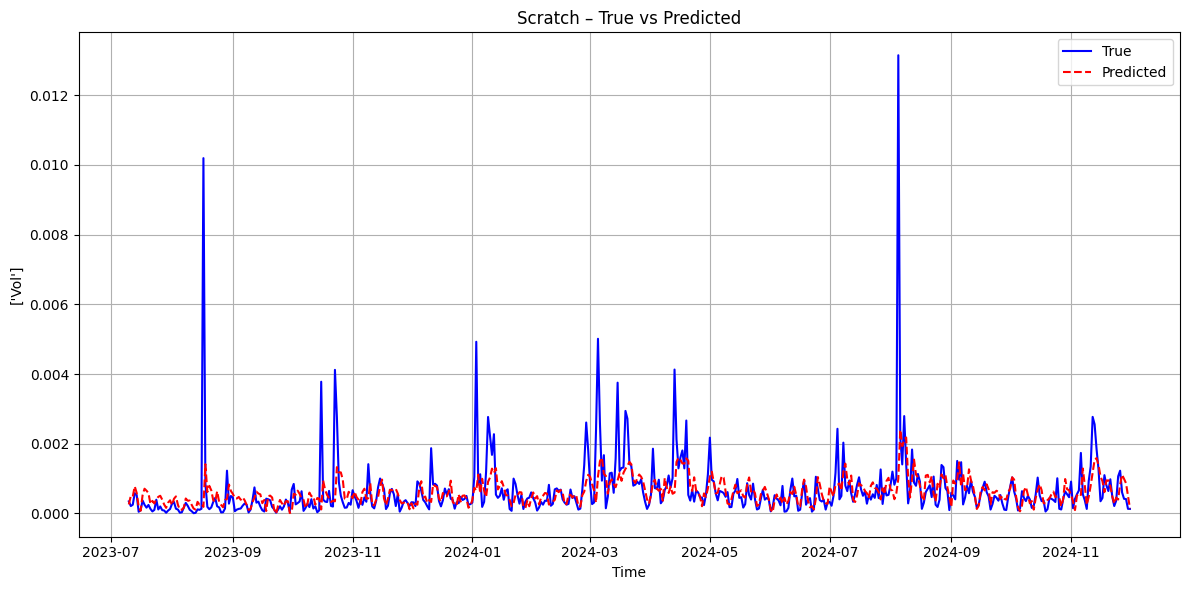

Carregando modelo: context256_lags5_useTrue_v2
Configurações extraídas - Context Length: 256, Lags: 5, Use Mean Features: False
Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade



=== Scratch ===
MSE: 8.078752e-07
MAE: 3.659714e-04
RMSE: 8.988188e-04
MAPE: 9.039714e+01


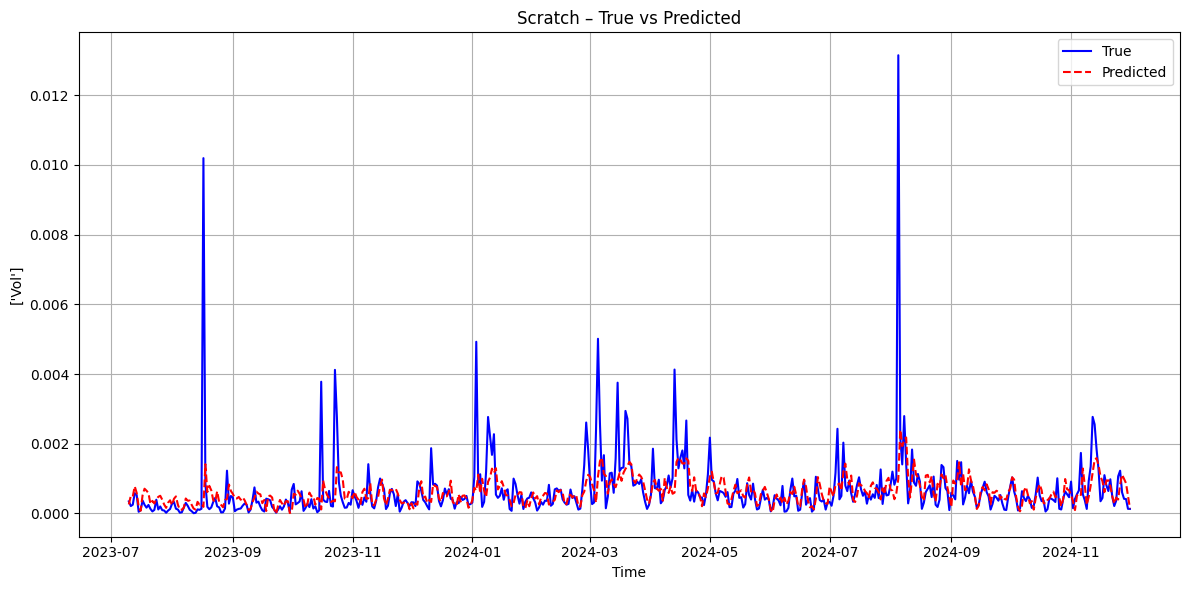

In [3]:
import os

modelos = os.listdir('../models/patchtst')
repo = RepositorioDados()

def parse_model_name(model_name):
    base_name = model_name.split('_v')[0]
    parts = base_name.split('_')
    context_length = int(parts[0].replace('context', ''))
    lags = int(parts[1].replace('lags', ''))
    use_mean_features = parts[2].replace('use_mean_features', '') == 'True'
    return context_length, lags, use_mean_features

def get_model(model_name):
    model_path = f'../models/patchtst/{model_name}'
    print(f"Carregando modelo: {model_name}")
    config = PatchTSTConfig.from_pretrained(model_path)

    model = PatchTSTForPrediction.from_pretrained(
        model_path,
        config=config,
        local_files_only=True,
        dtype=dtype
).to(device)

    model.eval()

    context_length, lags, use_mean_features = parse_model_name(model_name)
    print(f"Configurações extraídas - Context Length: {context_length}, Lags: {lags}, Use Mean Features: {use_mean_features}")

    repo = RepositorioDados()
    tsp, _, _, test_ds, _, _, _ = repo.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=context_length, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=FORECAST_HORIZON, use_mean_features=use_mean_features, lags=lags)

    test_df = test_ds.datasets[0].data_df

    forecast, results = evaluate_and_visualize(
        model=model,
        test_dataset=test_ds,
        tsp=tsp,
        test_df=test_df,
        timestamp_col=TIMESTAMP_COLUMN,
        target_column=TARGET_COLUMN,
        context_length=context_length,
        model_name="Scratch"
        )

    return forecast, results

results = []
results += list(map(get_model, modelos))[0][1]

In [4]:
results

['MSE', 'MAE', 'RMSE', 'MAPE']